# 04 — Threshold Optimization (Business Cost)

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

try:
    ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
except NameError:
    ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
sys.path.insert(0, ROOT)
os.makedirs(os.path.join(ROOT, "outputs"), exist_ok=True)

from src.feature_engineering import build_features
from src.model import FraudEnsemble, LightGBMFraudModel, XGBoostFraudModel
from src.evaluation import fraud_metrics_at_threshold

TARGET = "isFraud"
DROP_COLS = ["TransactionID", TARGET]

In [2]:
with open(os.path.join(ROOT, "config.yaml")) as f:
    config = yaml.safe_load(f)

transactions = pd.read_csv(os.path.join(ROOT, "data", "raw", "train_transaction.csv"))
identity = pd.read_csv(os.path.join(ROOT, "data", "raw", "train_identity.csv"))
df = build_features(transactions, identity=identity)

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
for col in df[FEATURE_COLS].select_dtypes(include=["object"]).columns:
    df[col] = pd.Categorical(df[col]).codes

X = df[FEATURE_COLS].fillna(-999)
y = df[TARGET]
split_idx = int(len(X) * 0.80)
X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

import joblib

ensemble_path = os.path.join(ROOT, "outputs", "models", "fraud_ensemble.pkl")
if os.path.exists(ensemble_path):
    print(f"Loading saved ensemble from {ensemble_path}")
    ensemble = joblib.load(ensemble_path)
else:
    xgb_model = XGBoostFraudModel(
        params=config.get("xgboost"),
        fn_cost=config["costs"]["fn_cost"],
        fp_cost=config["costs"]["fp_cost"],
    )
    xgb_model.fit(X_train, y_train, X_val, y_val)
    lgb_model = LightGBMFraudModel(params=config.get("lightgbm"))
    lgb_model.fit(X_train, y_train, X_val, y_val)
    ensemble = FraudEnsemble(xgb_model, lgb_model, xgb_weight=0.6)
    ensemble.calibrate_threshold(X_val, y_val)
    joblib.dump(ensemble, ensemble_path)

y_score = ensemble.predict_proba(X_val)
cost_curve = ensemble.threshold_optimizer.cost_curve_
display(cost_curve.head(10))

Loading saved ensemble from C:\Users\Lenovo\OneDrive\github_projects\fraud-detection-ml\outputs\models\fraud_ensemble.pkl


,threshold,total_cost,recall,precision,tp,fp,fn,tn
0,0.010000,574100.0,1.000000,0.027839,3288,114820,0,0
1,0.014925,574100.0,1.000000,0.027839,3288,114820,0,0
2,0.019849,569280.0,1.000000,0.028068,3288,113856,0,964
3,0.024774,550945.0,0.998175,0.029000,3282,109889,6,4931
4,0.029698,523860.0,0.996350,0.030489,3276,104172,12,10648
5,0.034623,494375.0,0.994526,0.032298,3270,97975,18,16845
6,0.039548,468355.0,0.989964,0.034164,3255,92021,33,22799
7,0.044472,445095.0,0.984185,0.036094,3236,86419,52,28401
8,0.049397,425075.0,0.975669,0.038089,3208,81015,80,33805
9,0.054322,408560.0,0.965633,0.040070,3175,76062,113,38758


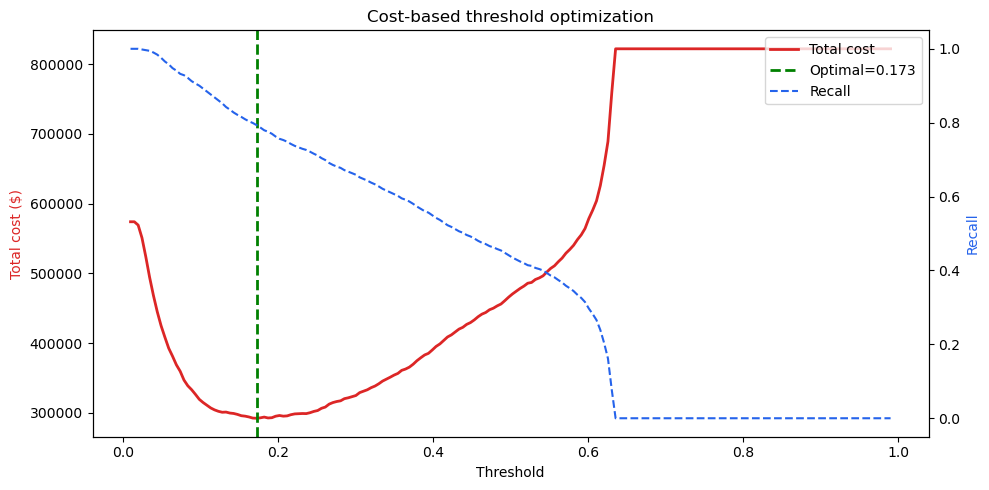

Saved C:\Users\Lenovo\OneDrive\github_projects\fraud-detection-ml\outputs\threshold_cost_curve.png


In [3]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(cost_curve["threshold"], cost_curve["total_cost"], color="#DC2626", lw=2, label="Total cost")
ax2.plot(cost_curve["threshold"], cost_curve["recall"], color="#2563EB", lw=1.5, linestyle="--", label="Recall")
opt = ensemble.threshold_optimizer.optimal_threshold_
ax1.axvline(opt, color="green", linestyle="--", lw=2, label=f"Optimal={opt:.3f}")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Total cost ($)", color="#DC2626")
ax2.set_ylabel("Recall", color="#2563EB")
ax1.set_title("Cost-based threshold optimization")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
out = os.path.join(ROOT, "outputs", "threshold_cost_curve.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out}")

,threshold,recall,precision,fpr,total_cost,cost_savings_vs_baseline
0,0.1000,0.8984,0.0592,0.4086,318090,256010
1,0.2000,0.7591,0.1132,0.1702,295730,278370
2,0.3000,0.6597,0.1941,0.0784,324765,249335
3,0.5000,0.4380,0.5322,0.0110,468330,105770
4,0.1725,0.7935,0.0961,0.2138,292465,281635


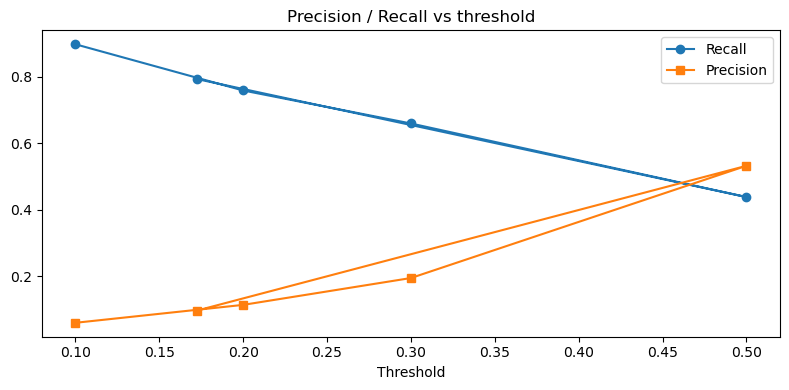

Saved C:\Users\Lenovo\OneDrive\github_projects\fraud-detection-ml\outputs\threshold_precision_recall.png


In [4]:
thresholds = [0.1, 0.2, 0.3, 0.5, opt]
rows = [fraud_metrics_at_threshold(y_val.values, y_score, t) for t in thresholds]
comparison = pd.DataFrame(rows)
display(comparison[["threshold", "recall", "precision", "fpr", "total_cost", "cost_savings_vs_baseline"]])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(comparison["threshold"], comparison["recall"], marker="o", label="Recall")
ax.plot(comparison["threshold"], comparison["precision"], marker="s", label="Precision")
ax.set_xlabel("Threshold")
ax.set_title("Precision / Recall vs threshold")
ax.legend()
plt.tight_layout()
out2 = os.path.join(ROOT, "outputs", "threshold_precision_recall.png")
plt.savefig(out2, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out2}")